Found 71 parquet files

Analyzing first 5 files...

File: 0.parquet
  Shape: (5442213, 4)
  Columns: ['subject_id', 'time', 'code', 'numeric_value']

File: 1.parquet
  Shape: (5356968, 4)
  Columns: ['subject_id', 'time', 'code', 'numeric_value']

File: 11.parquet
  Shape: (5556372, 4)
  Columns: ['subject_id', 'time', 'code', 'numeric_value']

File: 12.parquet
  Shape: (6137215, 4)
  Columns: ['subject_id', 'time', 'code', 'numeric_value']

File: 13.parquet
  Shape: (5600835, 4)
  Columns: ['subject_id', 'time', 'code', 'numeric_value']

Combined sample shape: (28093603, 4)

First few rows:
   subject_id                time  \
0    10000068 2141-01-01 00:00:00   
1    10000068 2160-03-03 00:00:00   
2    10000068 2160-03-03 21:55:00   
3    10000068 2160-03-04 06:26:00   
4    10000068 2160-03-04 06:26:00   

                                                code  numeric_value  
0                                         MEDS_BIRTH            NaN  
1                                    P

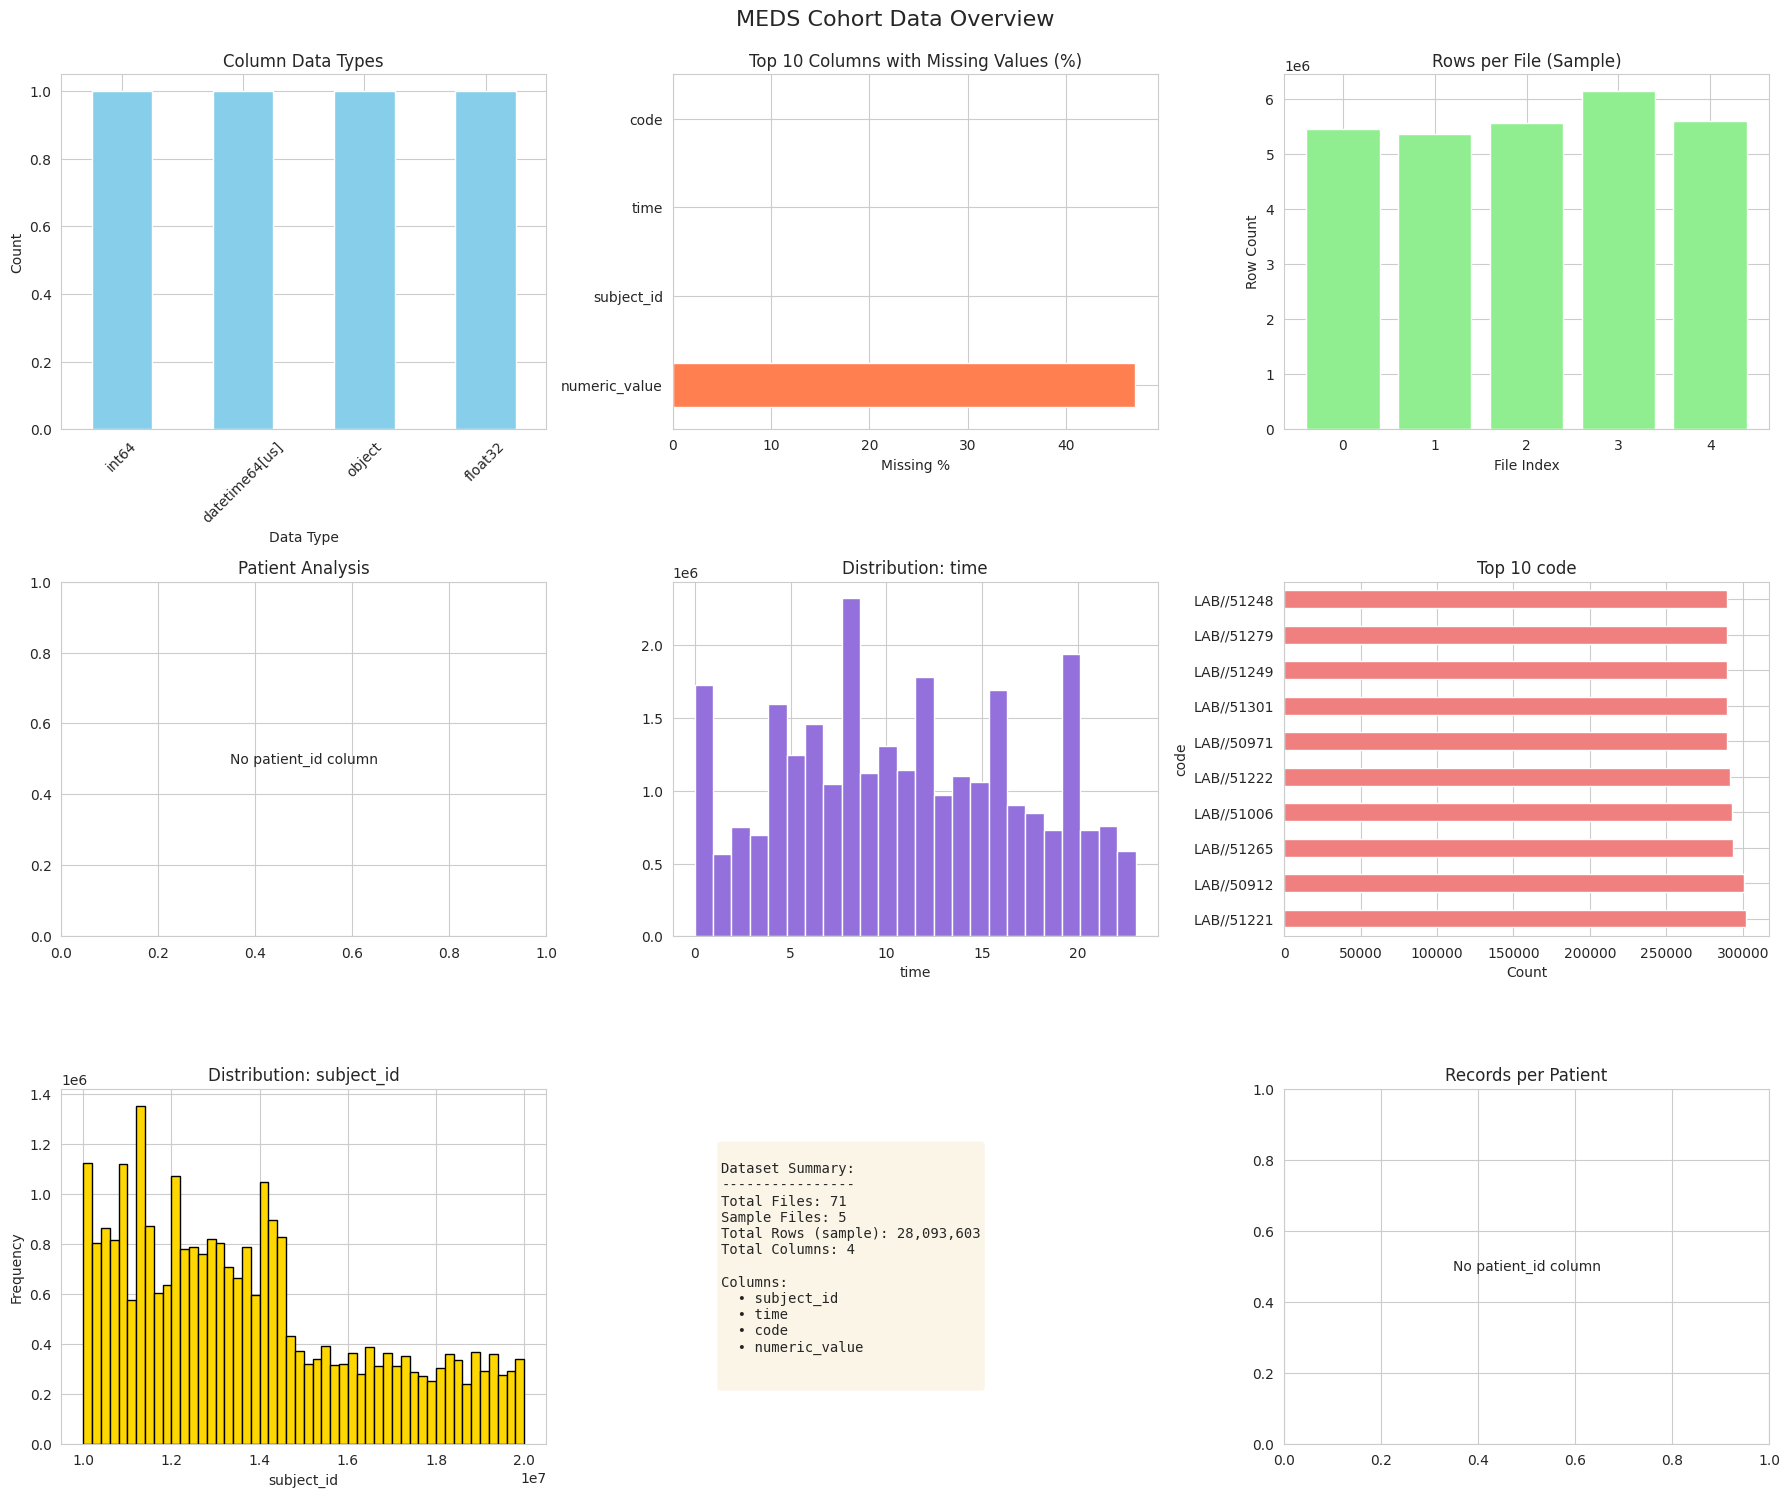


DETAILED SCHEMA
subject_id                int64
time             datetime64[us]
code                     object
numeric_value           float32
dtype: object

SAMPLE DATA
    subject_id                time  \
0     10000068 2141-01-01 00:00:00   
1     10000068 2160-03-03 00:00:00   
2     10000068 2160-03-03 21:55:00   
3     10000068 2160-03-04 06:26:00   
4     10000068 2160-03-04 06:26:00   
5     10000068 2160-03-04 07:33:47   
6     10000108 2138-01-01 00:00:00   
7     10000108 2163-09-16 16:34:00   
8     10000108 2163-09-24 16:14:00   
9     10000108 2163-09-27 16:18:00   
10    10000108 2163-09-27 18:55:00   
11    10000108 2163-09-27 18:55:00   
12    10000108 2163-09-27 18:55:00   
13    10000108 2163-09-27 18:55:00   
14    10000108 2163-09-27 18:55:00   
15    10000108 2163-09-27 18:55:00   
16    10000108 2163-09-27 18:55:00   
17    10000108 2163-09-27 18:55:00   
18    10000108 2163-09-27 18:55:00   
19    10000108 2163-09-27 18:55:00   

                             

In [3]:
# Visualize data set


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
from datetime import datetime

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Path to your data
data_path = "/hpc/group/kamaleswaranlab/capstone_icu_digital_twins/meds/MIMIC-IV_Example/data/MEDS_COHORT/data/train"

# Get all parquet files
parquet_files = sorted(glob.glob(f"{data_path}/*.parquet"))
print(f"Found {len(parquet_files)} parquet files")

# Sample a few files for initial exploration
sample_size = min(5, len(parquet_files))
sample_files = parquet_files[:sample_size]

print(f"\nAnalyzing first {sample_size} files...")

# Load and combine sample data
dfs = []
for file in sample_files:
    df = pd.read_parquet(file)
    dfs.append(df)
    print(f"\nFile: {Path(file).name}")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns)}")

# Combine sample data
combined_df = pd.concat(dfs, ignore_index=True)
print(f"\nCombined sample shape: {combined_df.shape}")
print(f"\nFirst few rows:")
print(combined_df.head())

# Create visualizations
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('MEDS Cohort Data Overview', fontsize=16, y=0.995)

# 1. Data type distribution
ax = axes[0, 0]
combined_df.dtypes.value_counts().plot(kind='bar', ax=ax, color='skyblue')
ax.set_title('Column Data Types')
ax.set_xlabel('Data Type')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

# 2. Missing values heatmap
ax = axes[0, 1]
missing_data = combined_df.isnull().sum()
missing_pct = (missing_data / len(combined_df) * 100).sort_values(ascending=False)
if len(missing_pct) > 0:
    missing_pct[:10].plot(kind='barh', ax=ax, color='coral')
    ax.set_title('Top 10 Columns with Missing Values (%)')
    ax.set_xlabel('Missing %')
else:
    ax.text(0.5, 0.5, 'No missing values', ha='center', va='center')
    ax.set_title('Missing Values')

# 3. Row count per file
ax = axes[0, 2]
row_counts = [len(pd.read_parquet(f)) for f in sample_files]
ax.bar(range(len(row_counts)), row_counts, color='lightgreen')
ax.set_title('Rows per File (Sample)')
ax.set_xlabel('File Index')
ax.set_ylabel('Row Count')

# 4. Unique patients (if patient_id exists)
ax = axes[1, 0]
if 'patient_id' in combined_df.columns:
    unique_patients = combined_df['patient_id'].nunique()
    total_records = len(combined_df)
    ax.bar(['Unique Patients', 'Total Records'], [unique_patients, total_records], 
           color=['steelblue', 'lightblue'])
    ax.set_title('Patient Count vs Records')
    ax.set_ylabel('Count')
    for i, v in enumerate([unique_patients, total_records]):
        ax.text(i, v, str(v), ha='center', va='bottom')
else:
    ax.text(0.5, 0.5, 'No patient_id column', ha='center', va='center')
    ax.set_title('Patient Analysis')

# 5. Time distribution (if time column exists)
ax = axes[1, 1]
time_cols = [col for col in combined_df.columns if 'time' in col.lower() or 'date' in col.lower()]
if time_cols:
    time_col = time_cols[0]
    try:
        if pd.api.types.is_numeric_dtype(combined_df[time_col]):
            combined_df[time_col].hist(bins=50, ax=ax, color='mediumpurple')
        else:
            pd.to_datetime(combined_df[time_col]).dt.hour.hist(bins=24, ax=ax, color='mediumpurple')
        ax.set_title(f'Distribution: {time_col}')
        ax.set_xlabel(time_col)
    except:
        ax.text(0.5, 0.5, f'Could not plot {time_col}', ha='center', va='center')
else:
    ax.text(0.5, 0.5, 'No time column found', ha='center', va='center')
    ax.set_title('Time Distribution')

# 6. Code/Event type distribution (if code column exists)
ax = axes[1, 2]
code_cols = [col for col in combined_df.columns if 'code' in col.lower() or 'event' in col.lower()]
if code_cols:
    code_col = code_cols[0]
    top_codes = combined_df[code_col].value_counts().head(10)
    top_codes.plot(kind='barh', ax=ax, color='lightcoral')
    ax.set_title(f'Top 10 {code_col}')
    ax.set_xlabel('Count')
else:
    ax.text(0.5, 0.5, 'No code column found', ha='center', va='center')
    ax.set_title('Code Distribution')

# 7. Numerical value distribution (if numeric_value exists)
ax = axes[2, 0]
numeric_cols = combined_df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    value_col = numeric_cols[0]
    combined_df[value_col].hist(bins=50, ax=ax, color='gold', edgecolor='black')
    ax.set_title(f'Distribution: {value_col}')
    ax.set_xlabel(value_col)
    ax.set_ylabel('Frequency')
else:
    ax.text(0.5, 0.5, 'No numeric columns', ha='center', va='center')
    ax.set_title('Numeric Distribution')

# 8. Column summary statistics
ax = axes[2, 1]
ax.axis('off')
summary_text = f"""
Dataset Summary:
----------------
Total Files: {len(parquet_files)}
Sample Files: {sample_size}
Total Rows (sample): {len(combined_df):,}
Total Columns: {len(combined_df.columns)}

Columns:
{chr(10).join([f"  • {col}" for col in combined_df.columns[:10]])}
{"  ..." if len(combined_df.columns) > 10 else ""}
"""
ax.text(0.1, 0.5, summary_text, fontsize=10, verticalalignment='center', 
        family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# 9. Records per patient distribution (if patient_id exists)
ax = axes[2, 2]
if 'patient_id' in combined_df.columns:
    records_per_patient = combined_df['patient_id'].value_counts()
    records_per_patient.hist(bins=50, ax=ax, color='teal', edgecolor='black')
    ax.set_title('Records per Patient Distribution')
    ax.set_xlabel('Number of Records')
    ax.set_ylabel('Number of Patients')
    ax.axvline(records_per_patient.mean(), color='red', linestyle='--', 
               label=f'Mean: {records_per_patient.mean():.1f}')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No patient_id column', ha='center', va='center')
    ax.set_title('Records per Patient')

plt.tight_layout()
plt.savefig('meds_data_overview.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed schema
print("\n" + "="*80)
print("DETAILED SCHEMA")
print("="*80)
print(combined_df.dtypes)
print("\n" + "="*80)
print("SAMPLE DATA")
print("="*80)
print(combined_df.head(20))

# Print value counts for categorical columns
print("\n" + "="*80)
print("CATEGORICAL COLUMN VALUE COUNTS")
print("="*80)
categorical_cols = combined_df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols[:5]:  # First 5 categorical columns
    print(f"\n{col}:")
    print(combined_df[col].value_counts().head(10))

In [ ]:
!

In [ ]:
import pandas as pd

df = pd.read_parquet("/hpc/home/aparedeslatorre1/icu_digital_twins_mamba/data/patient_sequences/patient_sequences_2048.parquet")
print(df.columns)
print(df.head(3))


: 